In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import Point, LineString, Polygon, MultiPoint, mapping
import numpy as np
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import plotly.express as px

In [3]:
# for the langoid CSV file 
df = pd.read_csv("glottolog_languoid.csv/languoid.csv") 
df.head() 

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET


In [6]:
df = pd.read_csv("mother_tongues_chart_dravidian.csv")
df.dropna()

,Group,Mother tongue,Total,Unnamed: 3,Unnamed: 4,Rural,Unnamed: 6,Unnamed: 7,Urban,Unnamed: 9,Unnamed: 10
0,NaN,NaN,P,M,F,P,M,F,P,M,F
1,NaN,NaN,1,2,3,4,5,6,7,8,9
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Assamese,ASSAMESE,15311351,7810583,7500768,13144701,6697715,6446986,2166650,1112868,1053782
4,Assamese,Assamese,14816414,7555350,7261064,12680101,6458345,6221756,2136313,1097005,1039308
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Malayalam,11 MALAYALAM,34838819,16712384,18126435,17411083,8366407,9044676,17427736,8345977,9081759
7,Malayalam,Malayalam,34776533,16681977,18094556,17355542,8339365,9016177,17420991,8342612,9078379
8,Malayalam,Pania,22808,11015,11793,19391,9340,10051,3417,1675,1742
9,Malayalam,Yerava,26563,13019,13544,25905,12694,13211,658,325,333


In [7]:
## change up the column names
df.columns = [
    "Group",
    "Mother tongue",
    "Total_P",
    "Total_M",
    "Total_F",
    "Rural_P",
    "Rural_M",
    "Rural_F",
    "Urban_P",
    "Urban_M",
    "Urban_F"
]

In [8]:
df = df.dropna(subset=["Group"]).reset_index(drop=True)

In [9]:
df

,Group,Mother tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,Assamese,ASSAMESE,15311351,7810583,7500768,13144701,6697715,6446986,2166650,1112868,1053782
1,Assamese,Assamese,14816414,7555350,7261064,12680101,6458345,6221756,2136313,1097005,1039308
2,Malayalam,11 MALAYALAM,34838819,16712384,18126435,17411083,8366407,9044676,17427736,8345977,9081759
3,Malayalam,Malayalam,34776533,16681977,18094556,17355542,8339365,9016177,17420991,8342612,9078379
4,Malayalam,Pania,22808,11015,11793,19391,9340,10051,3417,1675,1742
5,Malayalam,Yerava,26563,13019,13544,25905,12694,13211,658,325,333
6,Malayalam,11 Others,12915,6373,6542,10245,5008,5237,2670,1365,1305
7,Tamil,20 TAMIL,69026881,34600690,34426191,35627590,17878530,17749060,33399291,16722160,16677131
8,Tamil,Irula/Irular Mozhi,11870,5850,6020,11297,5564,5733,573,286,287
9,Tamil,Kaikadi,25870,12931,12939,9948,5021,4927,15922,7910,8012


In [10]:
### Level 1: LANGUAGE GROUPS

In [13]:
malayalam_df = df[df["Group"] =="Malayalam"]
malayalam_df

,Group,Mother tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
2,Malayalam,11 MALAYALAM,34838819,16712384,18126435,17411083,8366407,9044676,17427736,8345977,9081759
3,Malayalam,Malayalam,34776533,16681977,18094556,17355542,8339365,9016177,17420991,8342612,9078379
4,Malayalam,Pania,22808,11015,11793,19391,9340,10051,3417,1675,1742
5,Malayalam,Yerava,26563,13019,13544,25905,12694,13211,658,325,333
6,Malayalam,11 Others,12915,6373,6542,10245,5008,5237,2670,1365,1305


In [29]:
telugu_df = df[df["Group"] =="Telugu"]
telugu_df

,Group,Mother tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
14,Telugu,21 TELUGU,81127740,40658539,40469201,53845101,26972479,26872622,27282639,13686060,13596579
15,Telugu,Telugu,80912459,40549767,40362692,53738513,26918237,26820276,27173946,13631530,13542416
16,Telugu,Vadari,198020,99923,98097,96722,49253,47469,101298,50670,50628
17,Telugu,21 Others,17261,8849,8412,9866,4989,4877,7395,3860,3535


In [14]:
tamil_df = df[df["Group"] =="Tamil"]
tamil_df

,Group,Mother tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
7,Tamil,20 TAMIL,69026881,34600690,34426191,35627590,17878530,17749060,33399291,16722160,16677131
8,Tamil,Irula/Irular Mozhi,11870,5850,6020,11297,5564,5733,573,286,287
9,Tamil,Kaikadi,25870,12931,12939,9948,5021,4927,15922,7910,8012
10,Tamil,Korava,10421,5220,5201,5492,2743,2749,4929,2477,2452
11,Tamil,Tamil,68888839,34531580,34357259,35530671,17829882,17700789,33358168,16701698,16656470
12,Tamil,Yerukala/Yerukula,58065,29031,29034,39475,19803,19672,18590,9228,9362
13,Tamil,20 Others,31816,16078,15738,30707,15517,15190,1109,561,548


In [15]:
kannada_df = df[df["Group"] =="Kannada"]
kannada_df

,Group,Mother tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
18,Kannada,7 KANNADA,43706512,22111292,21595220,30738803,15522360,15216443,12967709,6588932,6378777
19,Kannada,Badaga,133550,63780,69770,81090,38645,42445,52460,25135,27325
20,Kannada,Kannada,43506272,22014001,21492271,30614889,15462374,15152515,12891383,6551627,6339756
21,Kannada,Kuruba/Kurumba,24189,11881,12308,21295,10462,10833,2894,1419,1475
22,Kannada,Prakritha/Prakritha Bhasha,12257,6372,5885,2868,1544,1324,9389,4828,4561
23,Kannada,7 Others,30244,15258,14986,18661,9335,9326,11583,5923,5660


In [16]:
tulu_df = df[df["Group"] =="Tulu"]
tulu_df

,Group,Mother tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
24,Tulu,117 TULU,22,11,11,8,6,2,14,5,9
25,Tulu,Tulu,11,6,5,1,1,0,10,5,5
26,Tulu,117 Others,11,5,6,7,5,2,4,0,4


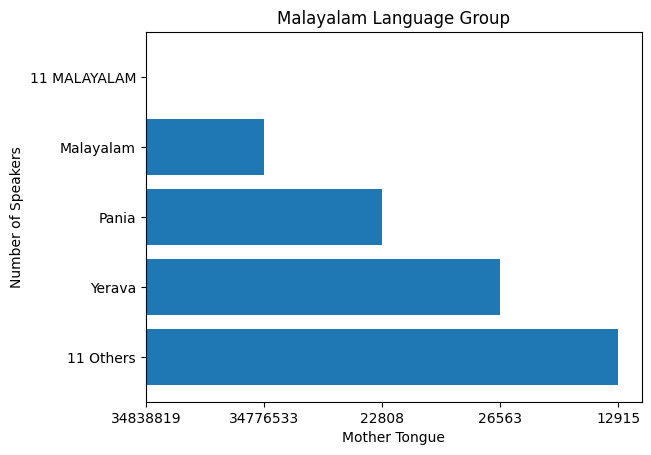

In [24]:
fig, ax = plt.subplots()

# Example data
ax.barh(
    malayalam_df["Mother tongue"],
    malayalam_df["Total_P"]
)
ax.set_ylabel("Number of Speakers")
ax.set_xlabel("Mother Tongue")
ax.set_title("Malayalam Language Group")
# to put largest item at the top if sorted
ax.invert_yaxis()      

plt.show()


In [ ]:
fig, ax = plt.subplots()

# Example data
ax.barh(
    tamil_df["Mother tongue"],
    tamil_df["Total_P"]
)
ax.set_ylabel("Number of Speakers")
ax.set_xlabel("Mother Tongue")
ax.set_title("Tamil Language Group")
# to put largest item at the top if sorted
ax.invert_yaxis()      

plt.show()


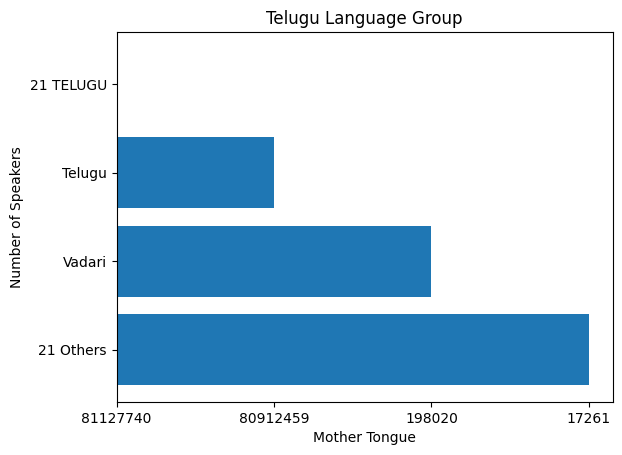

In [30]:
fig, ax = plt.subplots()

# Example data
ax.barh(
    telugu_df["Mother tongue"],
    telugu_df["Total_P"]
)
ax.set_ylabel("Number of Speakers")
ax.set_xlabel("Mother Tongue")
ax.set_title("Telugu Language Group")
# to put largest item at the top if sorted
ax.invert_yaxis()      

plt.show()

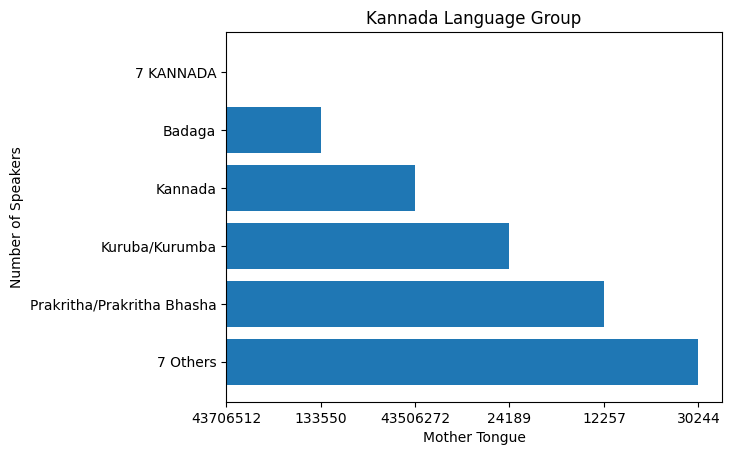

In [26]:
fig, ax = plt.subplots()

# Example data
ax.barh(
    kannada_df["Mother tongue"],
    kannada_df["Total_P"]
)
ax.set_ylabel("Number of Speakers")
ax.set_xlabel("Mother Tongue")
ax.set_title("Kannada Language Group")
# to put largest item at the top if sorted
ax.invert_yaxis()      

plt.show()

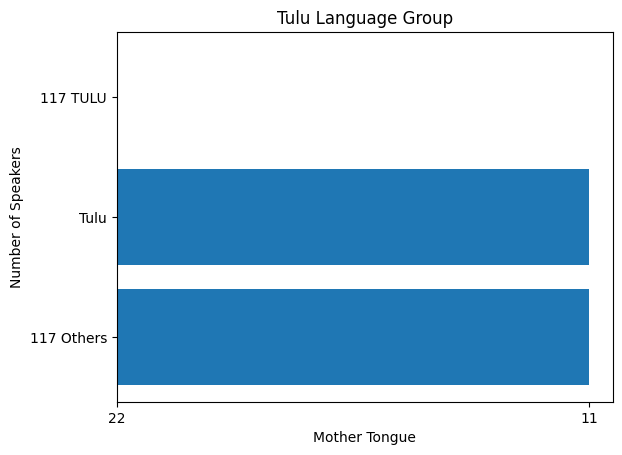

In [25]:
fig, ax = plt.subplots()

# Example data
ax.barh(
    tulu_df["Mother tongue"],
    tulu_df["Total_P"]
)
ax.set_ylabel("Number of Speakers")
ax.set_xlabel("Mother Tongue")
ax.set_title("Tulu Language Group")
# to put largest item at the top if sorted
ax.invert_yaxis()      

plt.show()